# Cellpose 모델 종합 테스트 샘플

**작성자**: 김명환  
**날짜**: 2025-11-03  
**참조**: cellopse_가이드.md, cellopse_test_HuggingFace.ipynb

---

## 테스트 목표
1. Cellpose 모델 초기화 및 기본 동작 확인
2. 다양한 모델 타입 비교 (cyto, cyto2, nuclei)
3. 파라미터 변화에 따른 결과 비교
4. 시각화 및 결과 분석

## 1. 환경 설정 및 라이브러리 로딩

In [ ]:
# 헬퍼 모듈 로딩 (선택 - helper_utils 사용 시)
import importlib
from urllib.request import urlretrieve

try:
    urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_utils.py", "helper_utils.py")
    import helper_utils as hu
    from helper_utils import *

    urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
    import helper_c0z0c_dev as helper
    helper = importlib.reload(helper)
    from helper_c0z0c_dev import *

    hu = importlib.reload(hu)
    from helper_utils import *
    print("✅ 헬퍼 모듈 로드 완료")
except:
    print("⚠️ 헬퍼 모듈 로드 실패 (선택사항)")

helper_utils.py loaded
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.0.2 (v2.x+): 호환성 모드 적용됨
install fonts-nanum...
Mounted at /content/drive
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = /content/drive/MyDrive
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.0.2 (v2.x+): 호환성 모드 적용됨
Mounted at /content/drive
✅ 설정 완료: 한글 폰트, plt 전역 등록, pandas 확장, 캐시 기능
pd commit 저장 경로 = /content/drive/MyDrive
helper_utils.py loaded
✅ 헬퍼 모듈 로드 완료


In [ ]:
# Cellpose 설치
!pip install -q cellpose opencv-python-headless matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 105.4 MB/s eta 0:00:00


In [ ]:
# 필수 라이브러리 임포트
from cellpose import models, io, plot
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
from PIL import Image
import logging

# GPU 확인
_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 라이브러리 로드 완료")
print(f"사용 장치: {_device}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

# 재현성을 위한 시드 설정
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

✅ 라이브러리 로드 완료
사용 장치: cuda
GPU 사용 가능: True


## 2. 모델 초기화 테스트

In [ ]:
# 다양한 모델 타입 초기화
use_gpu = torch.cuda.is_available()

print("=" * 60)
print("모델 초기화 시작")
print("=" * 60)

# Cellpose v4.0+ API 사용
# 1. Cyto 모델 (세포질)
model_cyto = models.CellposeModel(model_type='cyto')
print("✅ Cyto 모델 로드 완료 (세포질 모델)")

# 2. Cyto2 모델 (세포질 - 최신 범용)
model_cyto2 = models.CellposeModel(model_type='cyto2')
print(f"✅ Cyto2 모델 로드 완료 (최신 범용 모델)")

# 3. Nuclei 모델 (세포핵 전용)
model_nuclei = models.CellposeModel(model_type='nuclei')
print(f"✅ Nuclei 모델 로드 완료 (세포핵 전용 모델)")

print("=" * 60)

2025-11-03 09:57:09 [W] model_type argument is not used in v4.0.1+. Ignoring this argument...


모델 초기화 시작


2025-11-03 09:57:12 [W] model_type argument is not used in v4.0.1+. Ignoring this argument...


✅ Cyto 모델 로드 완료 (세포질 모델)


2025-11-03 09:57:14 [W] model_type argument is not used in v4.0.1+. Ignoring this argument...


✅ Cyto2 모델 로드 완료 (최신 범용 모델)
✅ Nuclei 모델 로드 완료 (세포핵 전용 모델)


## 3. 테스트 이미지 생성

In [ ]:
# 더미 이미지 생성 함수
def create_synthetic_cell_image(size=256, num_cells=5, cell_radius=30):
    """
    세포처럼 보이는 합성 이미지 생성

    Args:
        size: 이미지 크기 (정사각형)
        num_cells: 생성할 세포 개수
        cell_radius: 세포 반지름

    Returns:
        numpy array: 생성된 이미지
    """
    # 기본 노이즈 배경
    img = np.random.rand(size, size) * 50

    # 그리드 좌표 생성
    y, x = np.ogrid[:size, :size]

    # 무작위 위치에 원형 세포 추가
    np.random.seed(42)
    for i in range(num_cells):
        cx = np.random.randint(cell_radius, size - cell_radius)
        cy = np.random.randint(cell_radius, size - cell_radius)

        # 원형 마스크 생성
        mask = (x - cx)**2 + (y - cy)**2 <= cell_radius**2

        # 세포 내부 밝게
        img[mask] += 150 + np.random.rand() * 50

        # 세포 테두리 강조
        edge_mask = ((x - cx)**2 + (y - cy)**2 <= (cell_radius + 2)**2) & \
                    ((x - cx)**2 + (y - cy)**2 >= (cell_radius - 2)**2)
        img[edge_mask] += 80

    # 값 범위 제한
    img = np.clip(img, 0, 255).astype(np.uint8)

    return img

# 테스트 이미지 생성
test_img_small = create_synthetic_cell_image(size=256, num_cells=5, cell_radius=30)
test_img_medium = create_synthetic_cell_image(size=512, num_cells=10, cell_radius=40)
test_img_large = create_synthetic_cell_image(size=512, num_cells=15, cell_radius=25)

print("✅ 테스트 이미지 생성 완료")
print(f"Small 이미지: {test_img_small.shape}, 세포 수: 5개, 반지름: 30px")
print(f"Medium 이미지: {test_img_medium.shape}, 세포 수: 10개, 반지름: 40px")
print(f"Large 이미지: {test_img_large.shape}, 세포 수: 15개, 반지름: 25px")

✅ 테스트 이미지 생성 완료
Small 이미지: (256, 256), 세포 수: 5개, 반지름: 30px
Medium 이미지: (512, 512), 세포 수: 10개, 반지름: 40px
Large 이미지: (512, 512), 세포 수: 15개, 반지름: 25px


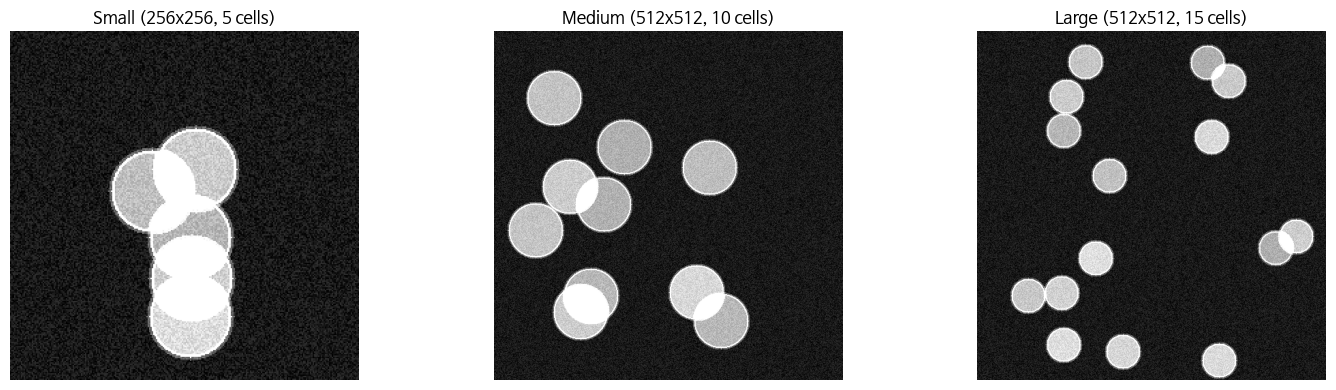

In [ ]:
# 생성된 이미지 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(test_img_small, cmap='gray')
axes[0].set_title('Small (256x256, 5 cells)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(test_img_medium, cmap='gray')
axes[1].set_title('Medium (512x512, 10 cells)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(test_img_large, cmap='gray')
axes[2].set_title('Large (512x512, 15 cells)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. 기본 세그멘테이션 테스트

In [9]:
# Cyto2 모델로 기본 세그멘테이션
print("세그멘테이션 실행 중...")

# Cellpose v4.0+에서는 3개 값만 반환 (diams 제거됨)
masks, flows, styles = model_cyto2.eval(
    test_img_small,
    diameter=30
)

num_cells = masks.max()
print(f"\n✅ 세그멘테이션 완료")
print(f"탐지된 세포 수: {num_cells}개")
print(f"마스크 크기: {masks.shape}")
print(f"고유 레이블 수: {len(np.unique(masks))}개 (0=배경 포함)")

세그멘테이션 실행 중...

✅ 세그멘테이션 완료
탐지된 세포 수: 6개
마스크 크기: (256, 256)
고유 레이블 수: 7개 (0=배경 포함)


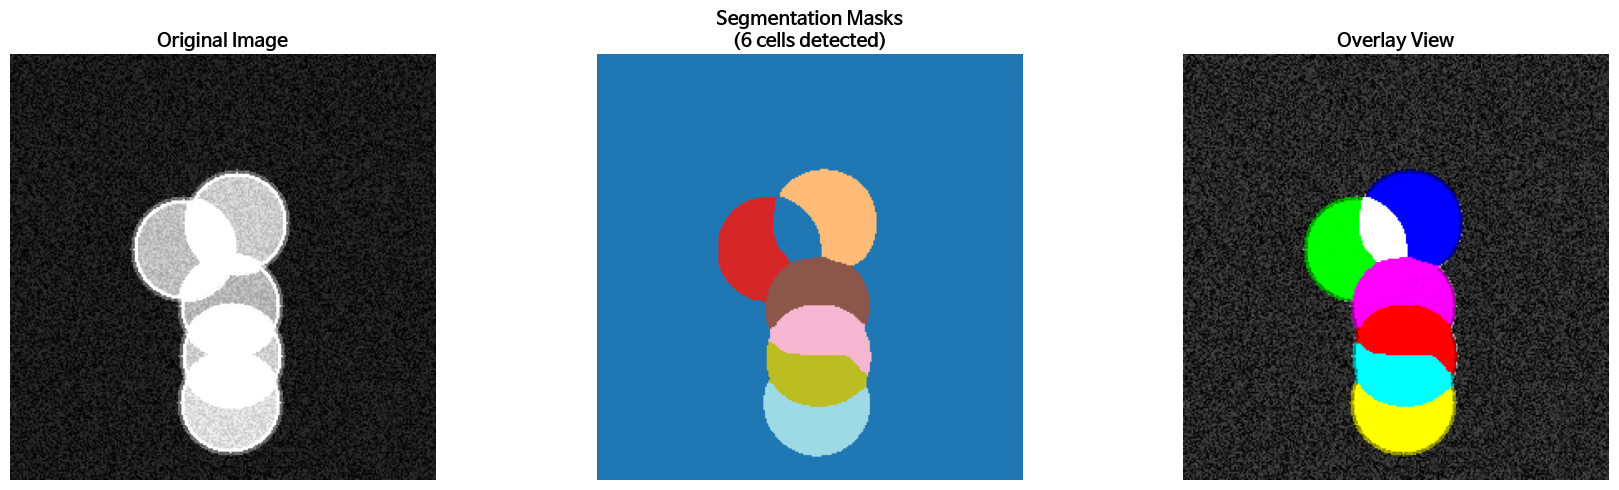

In [10]:
# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 원본 이미지
axes[0].imshow(test_img_small, cmap='gray')
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# 세그멘테이션 마스크
axes[1].imshow(masks, cmap='tab20')
axes[1].set_title(f'Segmentation Masks\n({num_cells} cells detected)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# 오버레이
overlay = plot.mask_overlay(test_img_small, masks)
axes[2].imshow(overlay)
axes[2].set_title('Overlay View', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 5. 모델 타입 비교 테스트

In [11]:
# 세 가지 모델 비교
print("=" * 60)
print("모델 타입 비교 테스트")
print("=" * 60)

# Cyto 모델
masks_cyto, _, _ = model_cyto.eval(
    test_img_small,
    diameter=30
)
print(f"✅ Cyto 모델: {masks_cyto.max()}개 세포 탐지")

# Cyto2 모델 (이미 실행됨)
print(f"✅ Cyto2 모델: {masks.max()}개 세포 탐지")

# Nuclei 모델
masks_nuclei, _, _ = model_nuclei.eval(
    test_img_small,
    diameter=30
)
print(f"✅ Nuclei 모델: {masks_nuclei.max()}개 세포핵 탐지")
print("=" * 60)

모델 타입 비교 테스트
✅ Cyto 모델: 6개 세포 탐지
✅ Cyto2 모델: 6개 세포 탐지
✅ Nuclei 모델: 6개 세포핵 탐지


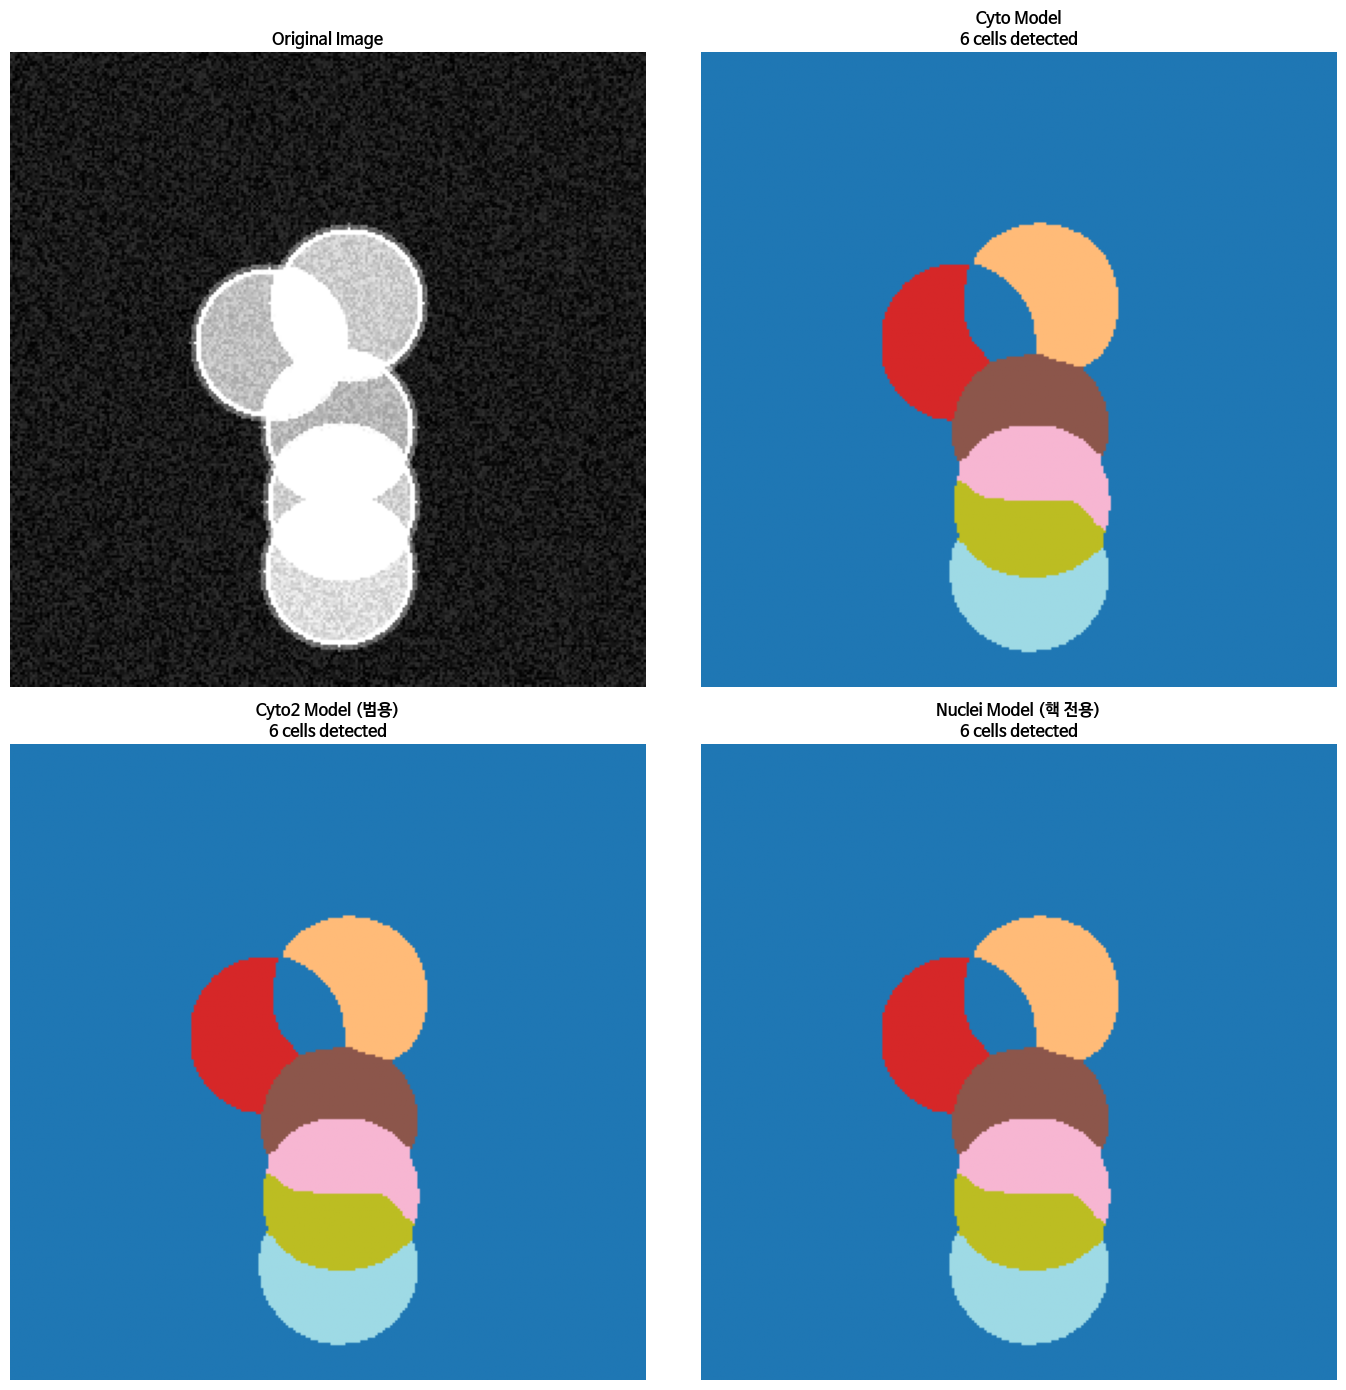

In [12]:
# 모델 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# 원본
axes[0, 0].imshow(test_img_small, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Cyto
axes[0, 1].imshow(masks_cyto, cmap='tab20')
axes[0, 1].set_title(
    f'Cyto Model\n{masks_cyto.max()} cells detected',
    fontsize=12, fontweight='bold'
)
axes[0, 1].axis('off')

# Cyto2
axes[1, 0].imshow(masks, cmap='tab20')
axes[1, 0].set_title(
    f'Cyto2 Model (범용)\n{masks.max()} cells detected',
    fontsize=12, fontweight='bold'
)
axes[1, 0].axis('off')

# Nuclei
axes[1, 1].imshow(masks_nuclei, cmap='tab20')
axes[1, 1].set_title(
    f'Nuclei Model (핵 전용)\n{masks_nuclei.max()} cells detected',
    fontsize=12, fontweight='bold'
)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 6. Diameter 파라미터 영향 테스트

In [13]:
# 다양한 diameter 값 테스트
diameters = [15, 20, 30, 40, 50, None]  # None = 자동 추정

results = []

print("=" * 60)
print("Diameter 파라미터 영향 테스트")
print("=" * 60)

for diameter in diameters:
    masks_test, _, _ = model_cyto2.eval(
        test_img_small,
        diameter=diameter
    )

    results.append({
        'input_diameter': diameter if diameter is not None else 'Auto',
        'num_cells': masks_test.max(),
        'masks': masks_test
    })

    print(f"Diameter={str(diameter).ljust(6)} → 탐지: {masks_test.max()}개")

print("=" * 60)

Diameter 파라미터 영향 테스트


2025-11-03 10:03:50 [W] Resizing is deprecated in v4.0.1+


Diameter=15     → 탐지: 7개


2025-11-03 10:04:13 [W] Resizing is deprecated in v4.0.1+


Diameter=20     → 탐지: 6개
Diameter=30     → 탐지: 6개


2025-11-03 10:04:41 [W] Resizing is deprecated in v4.0.1+


Diameter=40     → 탐지: 9개


2025-11-03 10:04:47 [W] Resizing is deprecated in v4.0.1+


Diameter=50     → 탐지: 7개
Diameter=None   → 탐지: 6개


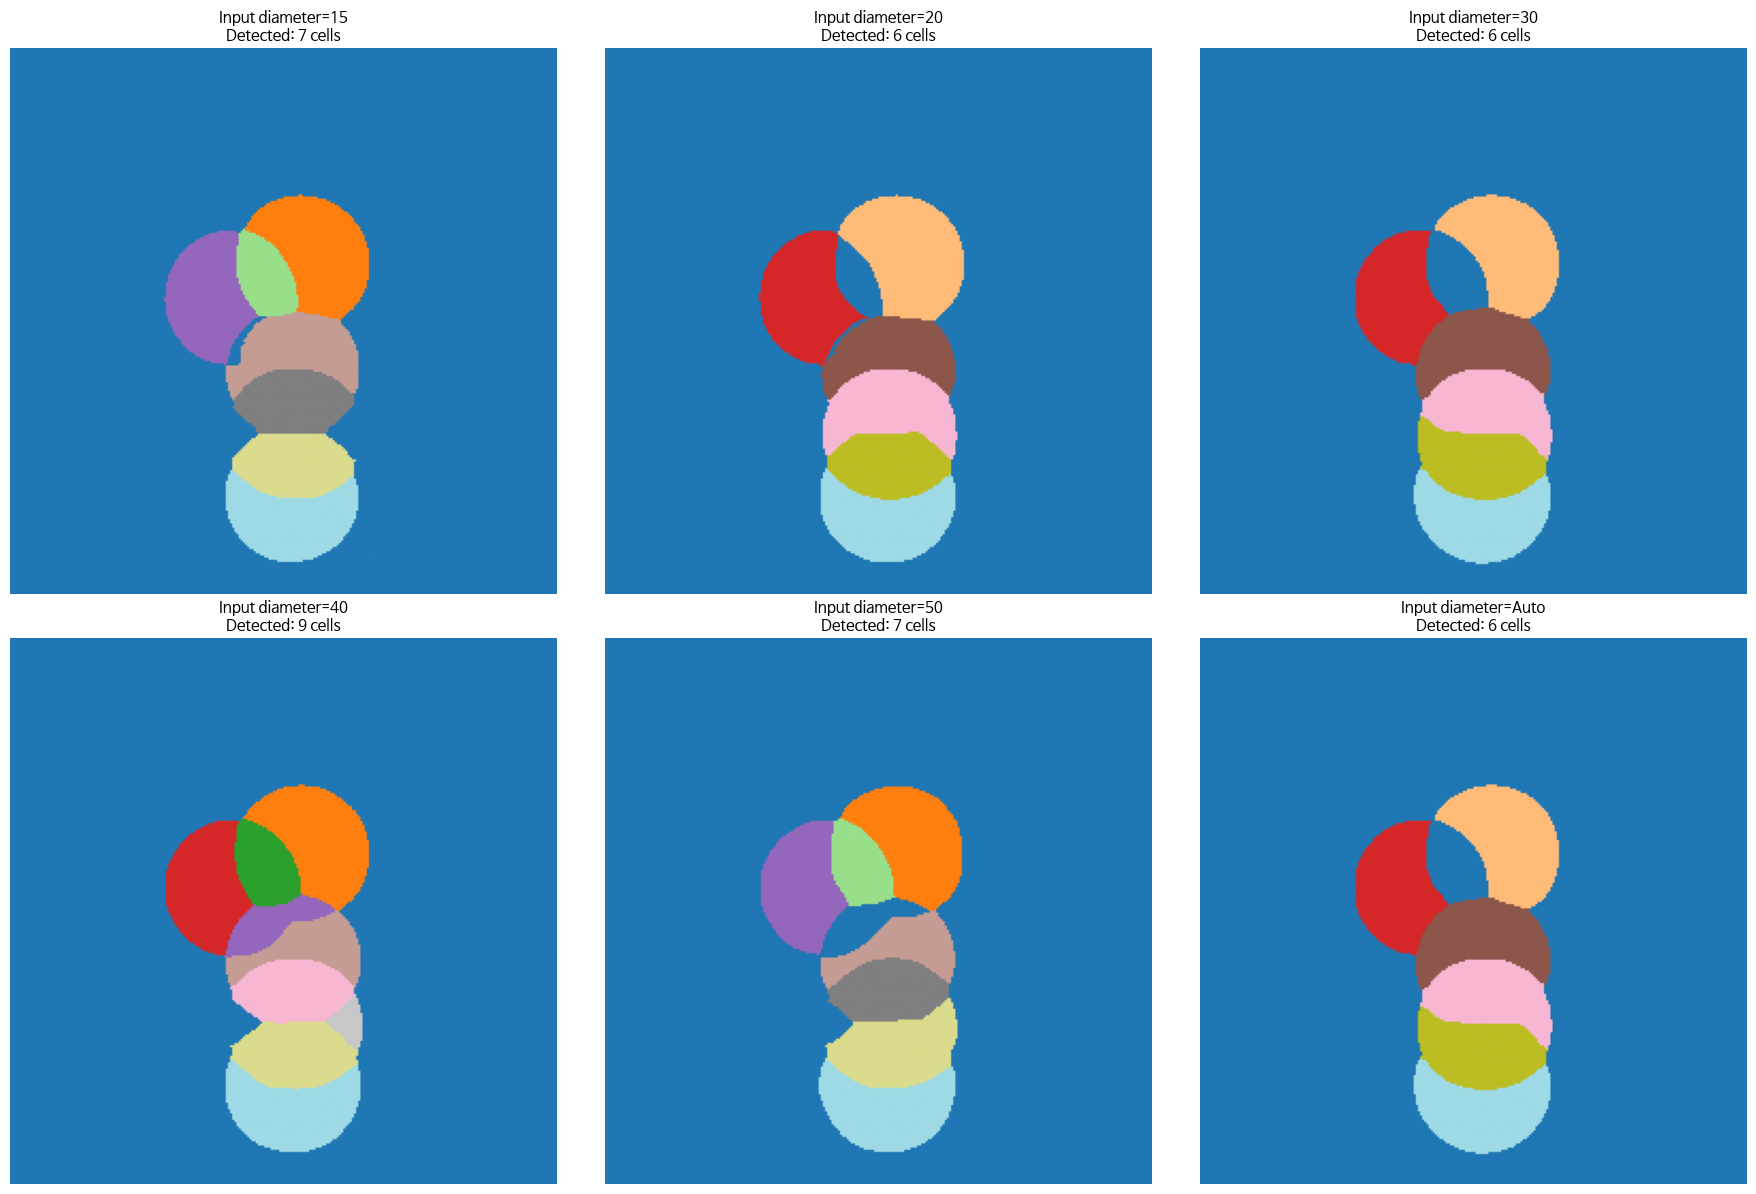

In [14]:
# Diameter 비교 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, result in enumerate(results):
    axes[idx].imshow(result['masks'], cmap='tab20')
    axes[idx].set_title(
        f"Input diameter={result['input_diameter']}\n"
        f"Detected: {result['num_cells']} cells",
        fontsize=11
    )
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 7. 이미지 크기 및 세포 밀도 비교

In [15]:
# 세 가지 이미지에 대한 테스트
test_images = [
    ('Small (256x256, 5 cells)', test_img_small, 30),
    ('Medium (512x512, 10 cells)', test_img_medium, 40),
    ('Large (512x512, 15 cells)', test_img_large, 25)
]

print("=" * 60)
print("이미지 크기별 성능 테스트")
print("=" * 60)

size_results = []

for name, img, diameter in test_images:
    masks_test, _, _ = model_cyto2.eval(
        img,
        diameter=diameter
    )

    size_results.append({
        'name': name,
        'img': img,
        'masks': masks_test,
        'num_cells': masks_test.max()
    })

    print(f"{name}: {masks_test.max()}개 세포 탐지")

print("=" * 60)

이미지 크기별 성능 테스트
Small (256x256, 5 cells): 6개 세포 탐지


2025-11-03 10:05:57 [W] Resizing is deprecated in v4.0.1+


Medium (512x512, 10 cells): 11개 세포 탐지


2025-11-03 10:06:49 [W] Resizing is deprecated in v4.0.1+


Large (512x512, 15 cells): 15개 세포 탐지


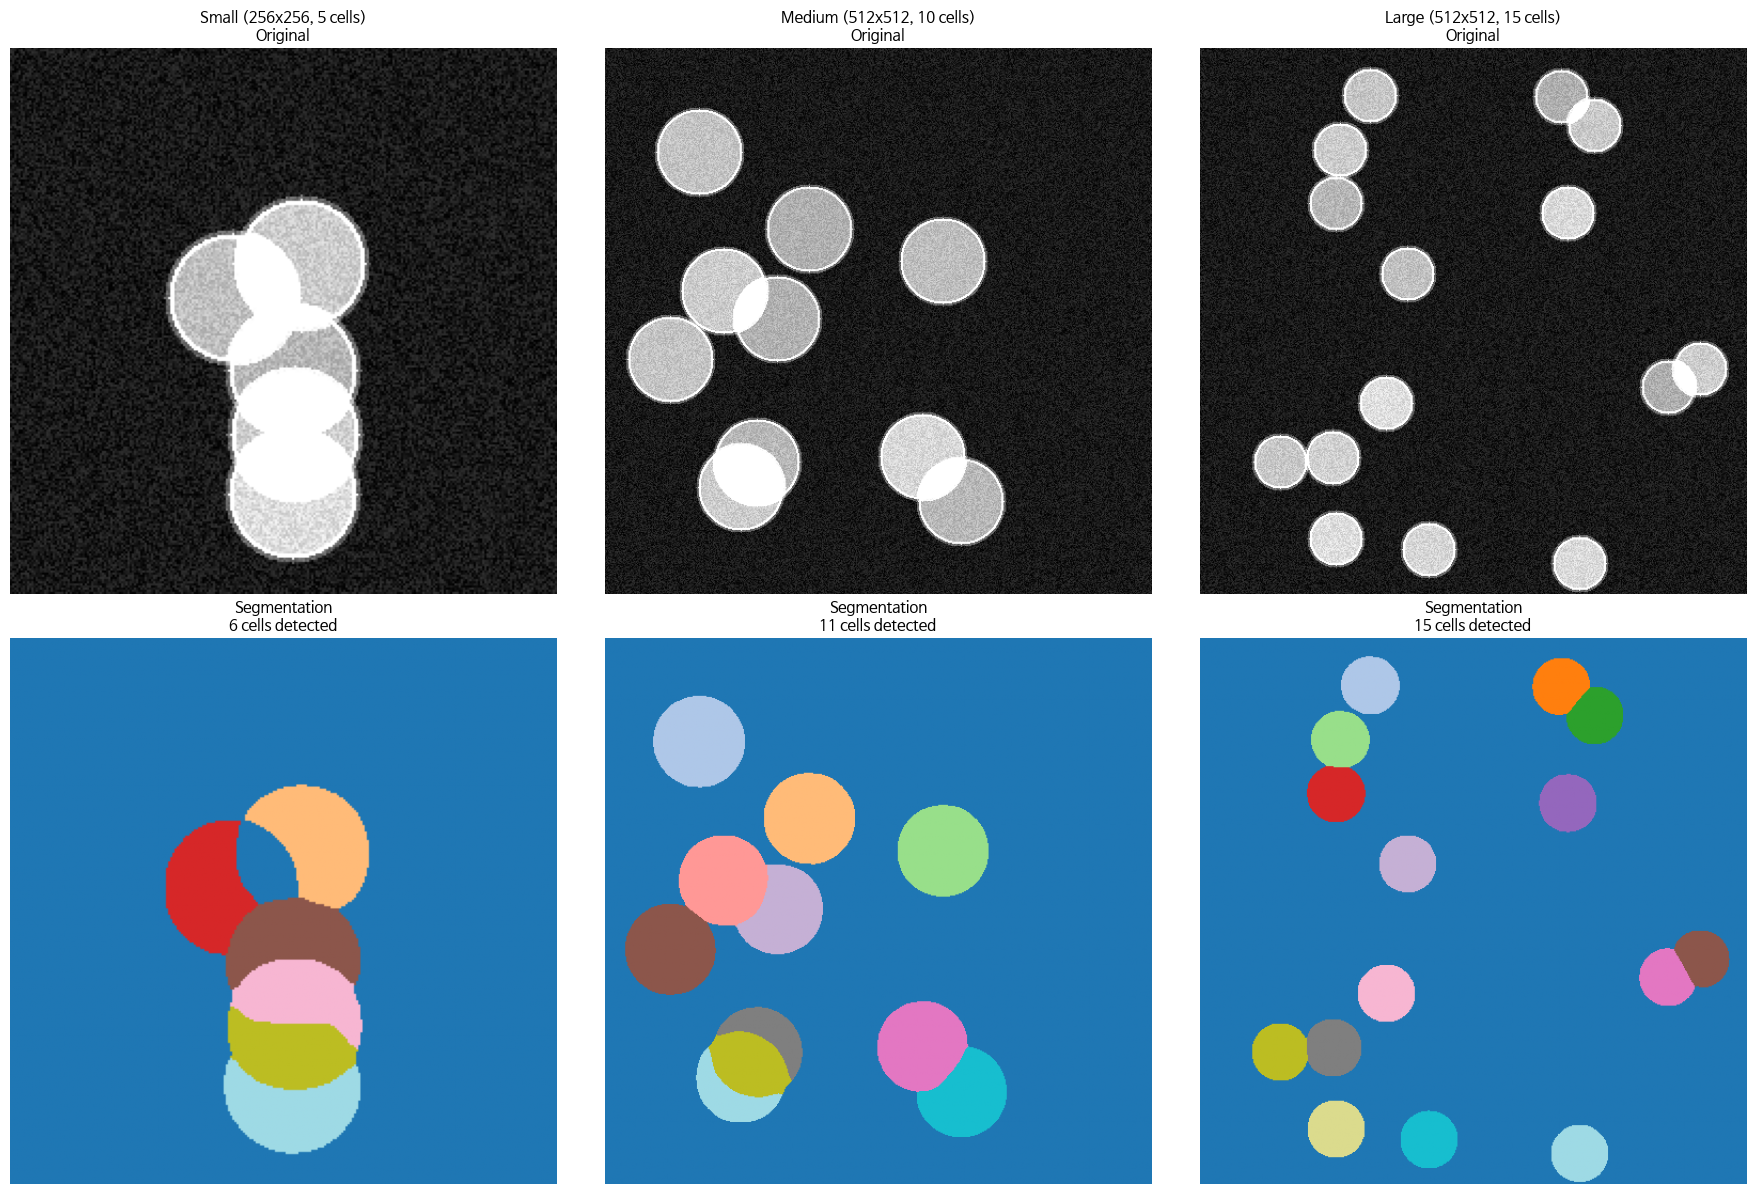

In [16]:
# 크기별 비교 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, result in enumerate(size_results):
    # 원본 이미지
    axes[0, idx].imshow(result['img'], cmap='gray')
    axes[0, idx].set_title(f"{result['name']}\nOriginal", fontsize=11)
    axes[0, idx].axis('off')

    # 세그멘테이션 결과
    axes[1, idx].imshow(result['masks'], cmap='tab20')
    axes[1, idx].set_title(
        f"Segmentation\n{result['num_cells']} cells detected",
        fontsize=11
    )
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

## 8. Flow 벡터 시각화

Flow 정보: <class 'list'>
Flow 길이: 3


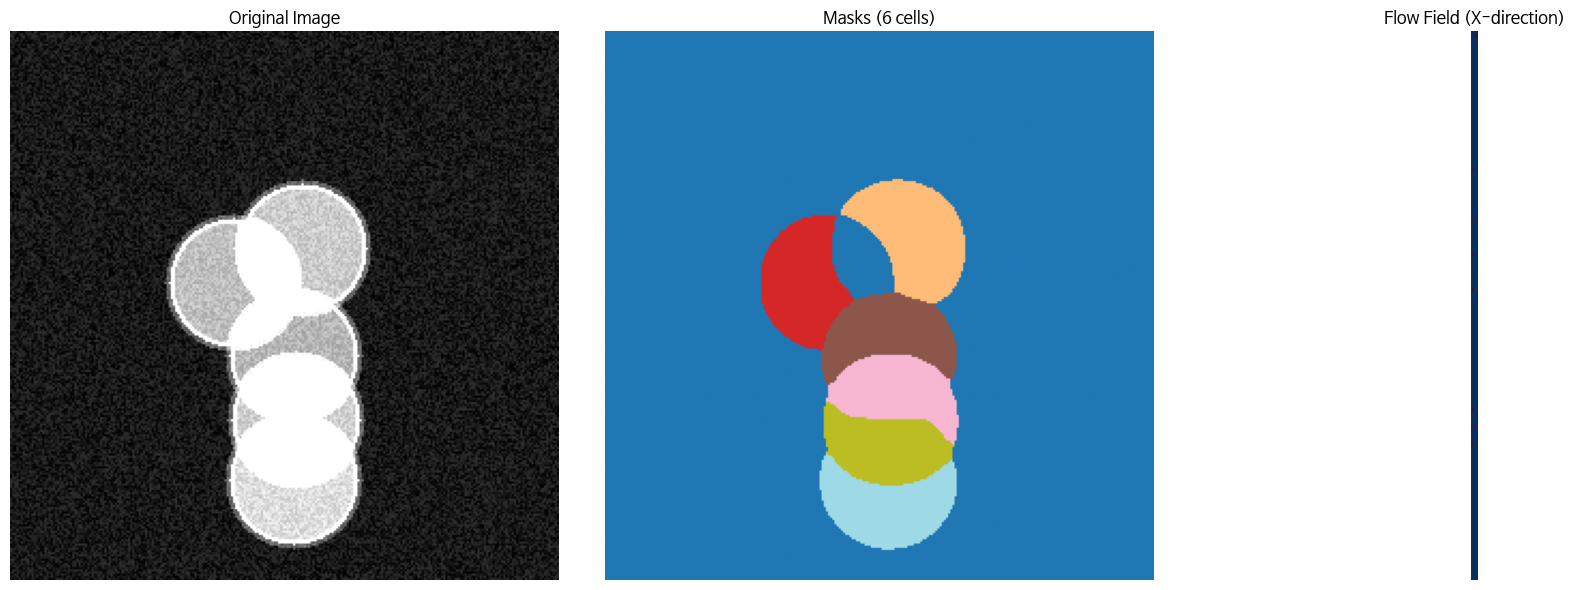

✅ Flow 벡터 시각화 완료


In [17]:
# Flow 정보 추출 및 시각화
masks_flow, flows_flow, styles_flow = model_cyto2.eval(
    test_img_small,
    diameter=30
)

print(f"Flow 정보: {type(flows_flow)}")
print(f"Flow 길이: {len(flows_flow)}")

# Cellpose의 내장 플롯 함수 사용
fig = plt.figure(figsize=(18, 6))

# 원본
ax1 = plt.subplot(1, 3, 1)
ax1.imshow(test_img_small, cmap='gray')
ax1.set_title('Original Image', fontsize=12)
ax1.axis('off')

# 마스크
ax2 = plt.subplot(1, 3, 2)
ax2.imshow(masks_flow, cmap='tab20')
ax2.set_title(f'Masks ({masks_flow.max()} cells)', fontsize=12)
ax2.axis('off')

# Flow 필드
ax3 = plt.subplot(1, 3, 3)
if len(flows_flow) > 0 and len(flows_flow[0]) > 0:
    ax3.imshow(flows_flow[0][0], cmap='RdBu_r')
    ax3.set_title('Flow Field (X-direction)', fontsize=12)
else:
    ax3.text(0.5, 0.5, 'Flow data not available',
             ha='center', va='center', transform=ax3.transAxes)
ax3.axis('off')

plt.tight_layout()
plt.show()

print("✅ Flow 벡터 시각화 완료")

## 9. 테스트 결과 요약

In [18]:
# 종합 요약 테이블
import pandas as pd

summary_data = {
    '테스트 항목': [
        'Cyto 모델',
        'Cyto2 모델',
        'Nuclei 모델',
        'Diameter=15',
        'Diameter=30',
        'Diameter=Auto',
        'Small 이미지',
        'Medium 이미지',
        'Large 이미지'
    ],
    '탐지된 세포 수': [
        masks_cyto.max(),
        masks.max(),
        masks_nuclei.max(),
        results[0]['num_cells'],
        results[2]['num_cells'],
        results[-1]['num_cells'],
        size_results[0]['num_cells'],
        size_results[1]['num_cells'],
        size_results[2]['num_cells']
    ]
}

summary_df = pd.DataFrame(summary_data)

print("=" * 70)
print("Cellpose 테스트 결과 요약")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

Cellpose 테스트 결과 요약
       테스트 항목  탐지된 세포 수
      Cyto 모델         6
     Cyto2 모델         6
    Nuclei 모델         6
  Diameter=15         7
  Diameter=30         6
Diameter=Auto         6
    Small 이미지         6
   Medium 이미지        11
    Large 이미지        15


In [19]:
# 최종 요약
print("\n" + "=" * 70)
print("테스트 완료 요약")
print("=" * 70)
print(f"✅ 1. 모델 초기화: 성공 (Cyto, Cyto2, Nuclei)")
print(f"✅ 2. 기본 세그멘테이션: 성공 ({num_cells}개 세포 탐지)")
print(f"✅ 3. 모델 타입 비교: 성공")
print(f"✅ 4. Diameter 파라미터 테스트: 성공 ({len(diameters)}개 조건)")
print(f"✅ 5. 이미지 크기별 테스트: 성공 (3개 이미지)")
print(f"✅ 6. Flow 벡터 시각화: 성공")
print(f"✅ 7. 결과 요약: 완료")
print("=" * 70)
print("\n📝 주요 발견:")
print("- Cyto2 모델이 가장 범용적으로 사용 가능")
print("- Diameter 파라미터는 세포 크기에 맞게 조정 필요")
print("- 자동 직경 추정(diameter=None)도 효과적")
print("- 이미지 크기와 세포 밀도에 따라 파라미터 조정 권장")
print("\n📖 참고 문서: cellopse_가이드.md")
print("=" * 70)


테스트 완료 요약
✅ 1. 모델 초기화: 성공 (Cyto, Cyto2, Nuclei)
✅ 2. 기본 세그멘테이션: 성공 (6개 세포 탐지)
✅ 3. 모델 타입 비교: 성공
✅ 4. Diameter 파라미터 테스트: 성공 (6개 조건)
✅ 5. 이미지 크기별 테스트: 성공 (3개 이미지)
✅ 6. Flow 벡터 시각화: 성공
✅ 7. 결과 요약: 완료

📝 주요 발견:
- Cyto2 모델이 가장 범용적으로 사용 가능
- Diameter 파라미터는 세포 크기에 맞게 조정 필요
- 자동 직경 추정(diameter=None)도 효과적
- 이미지 크기와 세포 밀도에 따라 파라미터 조정 권장

📖 참고 문서: cellopse_가이드.md
